<a href="https://colab.research.google.com/github/phanindra-max/Cross-Generator-Generalization-Project/blob/main/notebooks/02_train_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Section 2: Train Detection Models

Train two binary detectors on `data/splits/train.csv` (real FFHQ vs.
FaceSwap-c23 fakes):

1. **ConstrainedCNN** \u2014 Bayar & Stamm (2018) prediction-error front end.
2. **BaselineResNet** \u2014 ImageNet-pretrained ResNet50, fine-tuned.

Both checkpoints are then evaluated cross-generator in `03_cross_generator_eval.ipynb`.

`create_splits.py` only produced train / test_indist / test_ood \u2014 no val
split. Section 2.2 carves a stratified val set off `train.csv` with a
fixed seed so train and val are disjoint and reproducible.

## 0. Colab Setup

Three cells, idempotent: clone the repo if missing, mount Drive,
restore the tarred datasets and (if any) prior checkpoints.

In [1]:
import os
from pathlib import Path

REPO_URL  = "https://github.com/phanindra-max/Cross-Generator-Generalization-Project.git"
REPO_NAME = "Cross-Generator-Generalization-Project"

if not Path("src").exists() and not Path(REPO_NAME).exists():
    !git clone -q {REPO_URL}

if Path(REPO_NAME, "src").exists() and not Path("src").exists():
    %cd {REPO_NAME}

!pip install -q uv
!uv pip install -q -r requirements.txt

/content/Cross-Generator-Generalization-Project


In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path(".").resolve()
assert (PROJECT_ROOT / "src").exists(), f"src/ not found under {PROJECT_ROOT}"
sys.path.insert(0, str(PROJECT_ROOT))
print(f"Working dir: {PROJECT_ROOT}")

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    DRIVE_BACKUP = Path("/content/drive/MyDrive/deepfake-cross-generator/backups")
    IN_COLAB = True
    print(f"Drive backup root: {DRIVE_BACKUP}")
except ImportError:
    IN_COLAB = False
    DRIVE_BACKUP = None
    print("Not in Colab \u2014 Drive mount skipped.")

Working dir: /content/Cross-Generator-Generalization-Project
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive backup root: /content/drive/MyDrive/deepfake-cross-generator/backups


In [3]:
# Restore data + (optionally) prior checkpoints from Drive. Idempotent: only
# extracts when the local target is empty, so re-running is safe.
# Note: a directory containing only dotfiles (e.g. .gitkeep, committed in the
# repo as a placeholder) is treated as empty so the restore proceeds.
import subprocess

ARTIFACTS = [
    ("data/real",           "real.tar"),
    ("data/faceswap",       "faceswap.tar"),
    ("data/diffusion_sd15", "diffusion_sd15.tar"),
    ("data/splits",         "splits.tar"),
    # Optional — lets a fresh runtime resume eval without retraining.
    ("results/checkpoints", "checkpoints.tar"),
    ("results/metrics",     "metrics.tar"),
]

def _is_empty(p: Path) -> bool:
    if not p.exists():
        return True
    return not any(not child.name.startswith(".") for child in p.iterdir())

if IN_COLAB and DRIVE_BACKUP and DRIVE_BACKUP.exists():
    for local, archive in ARTIFACTS:
        target = Path(local)
        src = DRIVE_BACKUP / archive
        if not _is_empty(target):
            print(f"  skip {local}: already populated")
            continue
        if not src.exists():
            print(f"  miss {local}: no archive in Drive yet")
            continue
        target.parent.mkdir(parents=True, exist_ok=True)
        subprocess.run(["tar", "-xf", str(src), "-C", str(target.parent)], check=True)
        print(f"  ok   {local} restored from {archive}")
else:
    print("No Drive backup root — skipping restore.")

# If train.csv is still missing here, the splits weren't backed up to Drive.
# Regenerate them on the fly from the now-present image dirs.
if not Path("data/splits/train.csv").exists():
    print("\ndata/splits/train.csv missing — regenerating from data/{real,faceswap,diffusion_sd15}/...")
    from src.data.create_splits import create_splits
    create_splits(
        real_dir="data/real",
        faceswap_dir="data/faceswap",
        diffusion_dir="data/diffusion_sd15",
        output_dir="data/splits",
        seed=42,
    )
    print("Regenerated splits. Consider backing them up to Drive (notebook 00, Cell B).")

assert Path("data/splits/train.csv").exists(), \
    "data/splits/train.csv missing — run 00_data_pipeline first."

  skip data/real: already populated
  skip data/faceswap: already populated
  ok   data/diffusion_sd15 restored from diffusion_sd15.tar
  ok   data/splits restored from splits.tar
  ok   results/checkpoints restored from checkpoints.tar
  ok   results/metrics restored from metrics.tar


## 2.0 Imports & device

In [4]:
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import DataLoader

from src.data.faceforensics_loader import FaceForensicsDataset
from src.models.constrained_cnn import ConstrainedCNN
from src.models.baseline_resnet import BaselineResNet
from src.evaluation.stratified_metrics import compute_metrics

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
  GPU: Tesla T4


## 2.1 Hyperparameters and paths

In [5]:
CFG = {
    "seed":          42,
    "val_fraction":  0.15,    # carved off train.csv
    "epochs":        10,
    "batch_size":    32,
    "num_workers":   2,
    "lr":            1e-4,
    "weight_decay":  1e-5,
    "resolution":    128,
}

SPLITS_DIR     = Path("data/splits")
CHECKPOINT_DIR = Path("results/checkpoints_bayar")
METRICS_DIR    = Path("results/metrics")
for d in (CHECKPOINT_DIR, METRICS_DIR):
    d.mkdir(parents=True, exist_ok=True)

torch.manual_seed(CFG["seed"])
np.random.seed(CFG["seed"])
if DEVICE.type == "cuda":
    torch.cuda.manual_seed_all(CFG["seed"])

## 2.2 Carve a stratified val split off train.csv

Writes `train_only.csv` and `val.csv` next to the existing splits.
Idempotent: if both already exist with the right row counts, we reuse
them so the split stays deterministic across re-runs.

In [6]:
TRAIN_FULL = SPLITS_DIR / "train.csv"
TRAIN_OUT  = SPLITS_DIR / "train_only.csv"
VAL_OUT    = SPLITS_DIR / "val.csv"

df_full = pd.read_csv(TRAIN_FULL)
expected_val = int(round(len(df_full) * CFG["val_fraction"]))
expected_train = len(df_full) - expected_val

needs_split = True
if TRAIN_OUT.exists() and VAL_OUT.exists():
    if len(pd.read_csv(VAL_OUT)) == expected_val and len(pd.read_csv(TRAIN_OUT)) == expected_train:
        needs_split = False
        print(f"Reusing existing split: {expected_train} train / {expected_val} val")

if needs_split:
    train_df, val_df = train_test_split(
        df_full,
        test_size=CFG["val_fraction"],
        stratify=df_full["label"],
        random_state=CFG["seed"],
    )
    train_df.to_csv(TRAIN_OUT, index=False)
    val_df.to_csv(VAL_OUT, index=False)
    print(f"Wrote {TRAIN_OUT.name}: {len(train_df)} rows")
    print(f"Wrote {VAL_OUT.name}:   {len(val_df)} rows")

for path in (TRAIN_OUT, VAL_OUT):
    df = pd.read_csv(path)
    print(f"  {path.name:<16} label balance: {df['label'].value_counts().to_dict()}")

Wrote train_only.csv: 2720 rows
Wrote val.csv:   480 rows
  train_only.csv   label balance: {1: 1360, 0: 1360}
  val.csv          label balance: {0: 240, 1: 240}


## 2.3 Transforms and DataLoaders

In [7]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tf = A.Compose([
    A.Resize(CFG["resolution"], CFG["resolution"]),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])
eval_tf = A.Compose([
    A.Resize(CFG["resolution"], CFG["resolution"]),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

def make_loader(csv_path: str, transform, shuffle: bool):
    ds = FaceForensicsDataset(csv_path=csv_path, transform=transform)
    return DataLoader(
        ds,
        batch_size=CFG["batch_size"],
        shuffle=shuffle,
        num_workers=CFG["num_workers"],
        pin_memory=(DEVICE.type == "cuda"),
    )

train_loader = make_loader(str(TRAIN_OUT), train_tf, shuffle=True)
val_loader   = make_loader(str(VAL_OUT),   eval_tf,  shuffle=False)
print(f"train batches: {len(train_loader)}  val batches: {len(val_loader)}")

train batches: 85  val batches: 15


## 2.4 Training loop

Mirrors the logic in `src/training/train.py` but in a single function we can
call once per model. Saves the best-AUC checkpoint to `results/checkpoints/`.

In [8]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(loader, desc="train", leave=False):
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        # Bayar Algorithm 1: hard-project the constrained front end onto its
        # constraint manifold AFTER each optimizer step. ResNet has no such
        # method, so this is a no-op for the baseline.
        if hasattr(model, "project_constraints"):
            model.project_constraints()
        total_loss += loss.item() * images.size(0)
        _, pred = outputs.max(1)
        correct += pred.eq(labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_labels, all_preds, all_probs = [], [], []
    for images, labels in tqdm(loader, desc="val", leave=False):
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        outputs = model(images)
        loss = criterion(outputs, labels)
        total_loss += loss.item() * images.size(0)
        probs = torch.softmax(outputs, dim=1)[:, 1]
        _, pred = outputs.max(1)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(pred.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
    avg_loss = total_loss / max(len(all_labels), 1)
    metrics = compute_metrics(all_labels, all_preds, all_probs)
    return avg_loss, metrics

def train_model(model, model_name: str):
    """Full train/val loop. Saves best-AUC checkpoint and returns history."""
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=CFG["lr"], weight_decay=CFG["weight_decay"])
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG["epochs"])

    ckpt_path = CHECKPOINT_DIR / f"{model_name}_best.pth"
    history = []
    best_auc = 0.0
    t0 = time.time()

    for epoch in range(1, CFG["epochs"] + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss,   val_metrics = evaluate(model, val_loader, criterion)
        scheduler.step()

        row = {
            "epoch":     epoch,
            "train_loss": train_loss,
            "train_acc":  train_acc,
            "val_loss":   val_loss,
            "val_acc":    val_metrics["accuracy"],
            "val_auc":    val_metrics["auc"],
            "val_f1":     val_metrics["f1"],
        }
        history.append(row)
        msg = (f"epoch {epoch:02d}/{CFG['epochs']}  "
               f"train_loss={train_loss:.4f} train_acc={train_acc:.4f}  "
               f"val_loss={val_loss:.4f} val_acc={val_metrics['accuracy']:.4f} "
               f"val_auc={val_metrics['auc']:.4f}")
        if val_metrics["auc"] > best_auc:
            best_auc = val_metrics["auc"]
            torch.save({
                "model_name":       model_name,
                "epoch":            epoch,
                "model_state_dict": model.state_dict(),
                "best_auc":         best_auc,
                "config":           CFG,
            }, ckpt_path)
            msg += "  *best*"
        print(msg)

    elapsed = time.time() - t0
    print(f"\n{model_name}: best val AUC = {best_auc:.4f} | trained in {elapsed/60:.1f} min")
    print(f"checkpoint: {ckpt_path}")

    history_df = pd.DataFrame(history)
    history_df.to_csv(METRICS_DIR / f"{model_name}_history.csv", index=False)
    return history_df, ckpt_path

## 2.5 Train ConstrainedCNN

In [9]:
constrained_history, constrained_ckpt = train_model(
    ConstrainedCNN(num_classes=2),
    model_name="constrained_cnn",
)
constrained_history.tail()

train:   0%|          | 0/85 [00:00<?, ?it/s]

val:   0%|          | 0/15 [00:00<?, ?it/s]

epoch 01/10  train_loss=0.3956 train_acc=0.8610  val_loss=0.1274 val_acc=0.9812 val_auc=0.9994  *best*


train:   0%|          | 0/85 [00:00<?, ?it/s]

val:   0%|          | 0/15 [00:00<?, ?it/s]

...

epoch 09/10  train_loss=0.0213 train_acc=0.9923  val_loss=0.0054 val_acc=1.0000 val_auc=1.0000


train:   0%|          | 0/85 [00:00<?, ?it/s]

val:   0%|          | 0/15 [00:00<?, ?it/s]

epoch 10/10  train_loss=0.0169 train_acc=0.9971  val_loss=0.0052 val_acc=1.0000 val_auc=1.0000

constrained_cnn: best val AUC = 1.0000 | trained in 1.2 min
checkpoint: results/checkpoints_bayar/constrained_cnn_best.pth


,epoch,train_loss,train_acc,val_loss,val_acc,val_auc,val_f1
5,6,0.027221,0.992647,0.010990,0.997917,1.0,0.997912
6,7,0.019713,0.995956,0.005695,1.000000,1.0,1.000000
7,8,0.017260,0.995956,0.005267,1.000000,1.0,1.000000
8,9,0.021337,0.992279,0.005388,1.000000,1.0,1.000000
9,10,0.016858,0.997059,0.005152,1.000000,1.0,1.000000


## 2.6 Train BaselineResNet (ResNet50, ImageNet-pretrained)

In [10]:
baseline_history, baseline_ckpt = train_model(
    BaselineResNet(num_classes=2, backbone="resnet50", pretrained=True),
    model_name="baseline_resnet",
)
baseline_history.tail()

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 136MB/s]


train:   0%|          | 0/85 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:744: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


val:   0%|          | 0/15 [00:00<?, ?it/s]

epoch 01/10  train_loss=0.0663 train_acc=0.9783  val_loss=0.0003 val_acc=1.0000 val_auc=1.0000  *best*


...

epoch 09/10  train_loss=0.0010 train_acc=0.9996  val_loss=0.0000 val_acc=1.0000 val_auc=1.0000


train:   0%|          | 0/85 [00:00<?, ?it/s]

val:   0%|          | 0/15 [00:00<?, ?it/s]

epoch 10/10  train_loss=0.0001 train_acc=1.0000  val_loss=0.0000 val_acc=1.0000 val_auc=1.0000

baseline_resnet: best val AUC = 1.0000 | trained in 2.5 min
checkpoint: results/checkpoints_bayar/baseline_resnet_best.pth


,epoch,train_loss,train_acc,val_loss,val_acc,val_auc,val_f1
5,6,0.000095,1.000000,0.000031,1.0,1.0,1.0
6,7,0.000085,1.000000,0.000029,1.0,1.0,1.0
7,8,0.000307,1.000000,0.000031,1.0,1.0,1.0
8,9,0.001035,0.999632,0.000029,1.0,1.0,1.0
9,10,0.000087,1.000000,0.000026,1.0,1.0,1.0


## 2.7 Quick training-curve plot

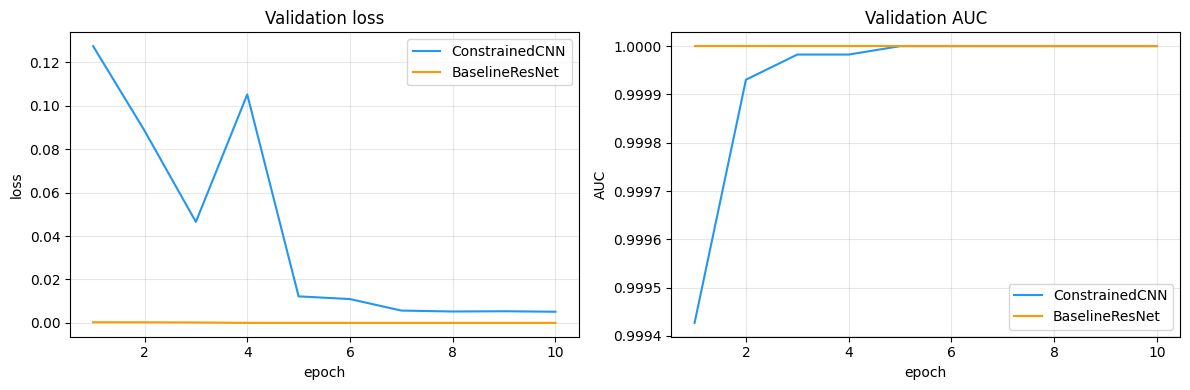

In [11]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for hist, name, color in [
    (constrained_history, "ConstrainedCNN", "#2196F3"),
    (baseline_history,    "BaselineResNet", "#FF9800"),
]:
    axes[0].plot(hist["epoch"], hist["val_loss"], label=name, color=color)
    axes[1].plot(hist["epoch"], hist["val_auc"],  label=name, color=color)
axes[0].set(title="Validation loss", xlabel="epoch", ylabel="loss")
axes[1].set(title="Validation AUC",  xlabel="epoch", ylabel="AUC")
for ax in axes:
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
Path("results/figures").mkdir(parents=True, exist_ok=True)
plt.savefig("results/figures/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 2.8 Back up checkpoints + metrics to Drive

Atomic tar-then-rename, same pattern as the data backups in notebook 00.
Run this once both models have finished training so a future runtime
can resume eval (notebook 03) without retraining.

In [12]:
if IN_COLAB and DRIVE_BACKUP is not None:
    DRIVE_BACKUP.mkdir(parents=True, exist_ok=True)
    for local, archive in [
        ("results/checkpoints", "checkpoints.tar"),
        ("results/metrics",     "metrics.tar"),
    ]:
        src = Path(local)
        if not src.exists() or not any(src.iterdir()):
            print(f"  skip {local}: empty")
            continue
        final = DRIVE_BACKUP / archive
        tmp = final.with_suffix(final.suffix + ".tmp")
        subprocess.run(["tar", "-cf", str(tmp), "-C", str(src.parent), src.name], check=True)
        tmp.replace(final)
        size_mb = final.stat().st_size / (1024 * 1024)
        print(f"  ok   {local} -> {archive} ({size_mb:.1f} MB)")
else:
    print("Not in Colab or no Drive \u2014 skipping checkpoint backup.")

  ok   results/checkpoints -> checkpoints.tar (93.6 MB)
  ok   results/metrics -> metrics.tar (0.0 MB)


## What's next

Run `03_cross_generator_eval.ipynb` to load these checkpoints and measure
the in-distribution vs. cross-generator (FaceSwap \u2192 Stable Diffusion)
transfer gap.